# Clasificador de edad por década

### Modificación respecto al estudio anterior: `Aumento del número de categorías`

**Este cambio se aplicó para estudiar como responden los modelos al modificar este parámetro**

Clasificación multiclase en 9 clases (una por década) a partir de fotos de rostros. Lo hicimos en PyTorch y en TensorFlow/Keras para comparar los dos frameworks.

Las categorías:

| Clase | Rango |
|---|---|
| 0 | 0-9 |
| 1 | 10-19 |
| 2 | 20-29 |
| 3 | 30-39 |
| 4 | 40-49 |
| 5 | 50-59 |
| 6 | 60-69 |
| 7 | 70-79 |
| 8 | 80+ |


# Desarrollo

In [1]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"     # carpeta única con todas las imágenes (sin subcarpetas por década)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [2]:
# --- Categorías por década y utilidades ---
CLASS_NAMES = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

# Códigos de etnia de UTKFace (campo 3 del nombre de archivo)
RACE_NAMES = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

def age_to_decade(age: int) -> int:
    """Convierte una edad entera al índice de década (0-8): 0-9, 10-19, ..., 80+."""
    return min(age // 10, 8)

def parse_race_from_filename(filename: str):
    """Extrae el código de etnia (0-4) del nombre '[edad]_[genero]_[raza]_[fecha].jpg'. None si no calza."""
    parts = os.path.basename(filename).split("_")
    try:
        race = int(parts[2])
        return race if race in RACE_NAMES else None
    except (ValueError, IndexError):
        return None

In [3]:
# --- Construcción del dataframe desde la carpeta única UTKFace ---
# La etiqueta (década) se calcula parseando la edad del NOMBRE DE ARCHIVO (no hay subcarpetas por década).
# Para balancear sin duplicar imágenes en disco: se muestrea aleatoriamente el mínimo común (cap)
# de imágenes por década, con semilla fija para reproducibilidad.
# Además guardamos la etnia (del nombre de archivo) para el análisis posterior.
all_fps = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
if len(all_fps) == 0:
    raise FileNotFoundError(
        f"No hay imágenes en '{DATA_DIR}'. Revisa que la carpeta UTKFace exista con los .jpg "
        "directamente adentro (ver celda de descarga del dataset)."
    )

records_by_class = {i: [] for i in range(len(CLASS_NAMES))}
skipped = 0
for fp in all_fps:
    age = parse_age_from_filename(fp)
    if age is None:
        skipped += 1
        continue
    records_by_class[age_to_decade(age)].append(fp)

print(f"Imágenes totales encontradas: {len(all_fps)}  |  Descartadas (nombre no calza el formato): {skipped}")
print("Disponibles por década (antes de balancear):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {len(records_by_class[i])}")

cap = min(len(fps) for fps in records_by_class.values())
print(f"\nCap por década (mínimo común): {cap}")

rng = np.random.RandomState(SEED)
records = []
for label_idx, fps in records_by_class.items():
    sampled = rng.choice(fps, size=cap, replace=False)
    for fp in sampled:
        records.append({"filepath": fp, "label": label_idx, "race": parse_race_from_filename(fp)})

df = pd.DataFrame(records, columns=["filepath", "label", "race"])
print(f"\nImágenes usadas para entrenar (balanceado): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes totales encontradas: 23708  |  Descartadas (nombre no calza el formato): 3
Disponibles por década (antes de balancear):
  0-9: 3062
  10-19: 1531
  20-29: 7344
  30-39: 4536
  40-49: 2245
  50-59: 2299
  60-69: 1316
  70-79: 699
  80+: 673

Cap por década (mínimo común): 673

Imágenes usadas para entrenar (balanceado): 6057
Por clase:
label
0-9      673
10-19    673
20-29    673
30-39    673
40-49    673
50-59    673
60-69    673
70-79    673
80+      673
Name: count, dtype: int64


,filepath,label,race
0,./UTKFace_data/UTKFace\3_1_0_20170109193833863...,0,0
1,./UTKFace_data/UTKFace\1_0_2_20161219154041477...,0,2
2,./UTKFace_data/UTKFace\2_1_0_20161219190909739...,0,0
3,./UTKFace_data/UTKFace\2_1_2_20161219162334438...,0,2
4,./UTKFace_data/UTKFace\2_1_4_20161221202428169...,0,4


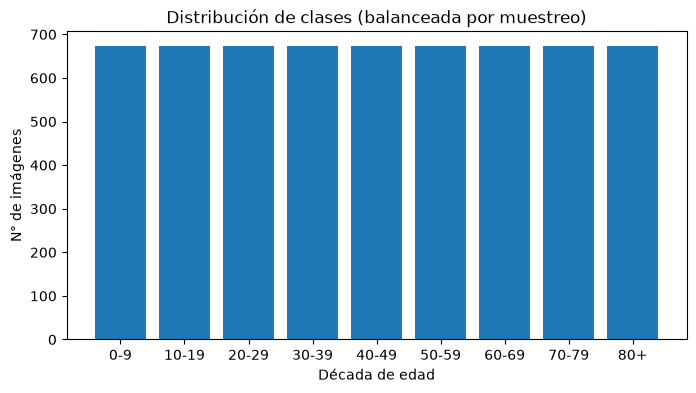

label
0-9      673
10-19    673
20-29    673
30-39    673
40-49    673
50-59    673
60-69    673
70-79    673
80+      673
Name: count, dtype: int64


In [4]:
# --- Distribución de clases (por década) ---
counts = df["label"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=0)
plt.figure(figsize=(8, 4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Distribución de clases (balanceada por muestreo)")
plt.ylabel("N° de imágenes")
plt.xlabel("Década de edad")
plt.show()

print(counts.rename(index=lambda i: CLASS_NAMES[i]))
# Balanceado por muestreo (cap = mínimo común entre décadas) -> barras del mismo alto.

Distribución de etnia por categoría de edad (%):

race_name  White  Black  Asian  Indian  Others
0-9         35.2    4.2   34.2    15.0    11.4
10-19       61.4   10.3    5.8    10.8    11.7
20-29       23.8   26.6   18.1    21.4    10.1
30-39       39.1   25.1   11.0    18.4     6.4
40-49       48.1   17.7    7.0    22.3     4.9
50-59       61.1   13.1    5.3    18.1     2.4
60-69       63.0   16.0    6.8    12.6     1.5
70-79       68.2   12.6   12.0     6.8     0.3
80+         71.8    8.6   15.2     3.9     0.6


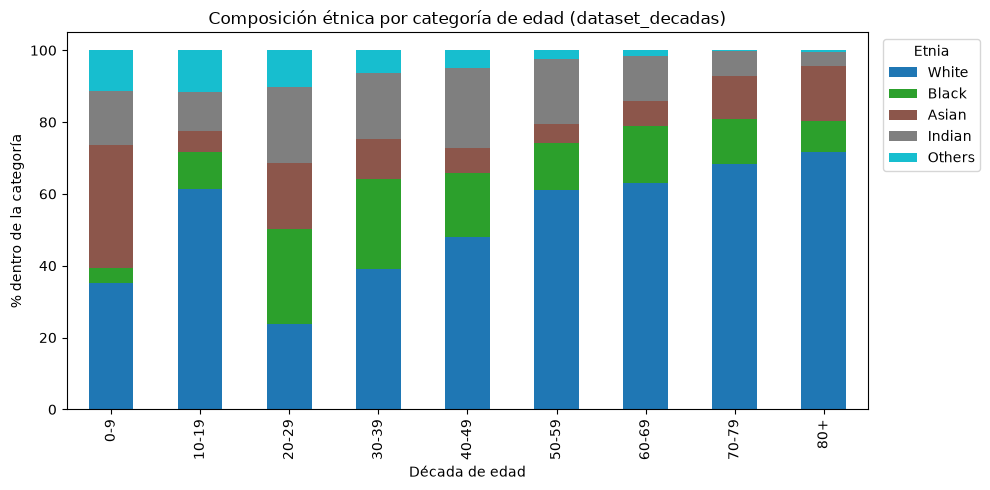

In [5]:
# --- Distribución por ETNIA dentro de cada categoría de edad ---
# Porcentaje de cada etnia (columnas) en cada década (filas).
tab = (
    df.assign(race_name=df["race"].map(RACE_NAMES))
      .pivot_table(index="label", columns="race_name", aggfunc="size", fill_value=0)
      .reindex(range(len(CLASS_NAMES)))
)
tab.index = [CLASS_NAMES[i] for i in tab.index]
tab = tab.reindex(columns=[RACE_NAMES[r] for r in range(5)], fill_value=0)

pct = tab.div(tab.sum(axis=1), axis=0) * 100  # % por fila

print("Distribución de etnia por categoría de edad (%):\n")
print(pct.round(1).to_string())

# Gráfico de barras apiladas (100% por categoría)
ax = pct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab10")
ax.set_title("Composición étnica por categoría de edad (dataset_decadas)")
ax.set_ylabel("% dentro de la categoría")
ax.set_xlabel("Década de edad")
ax.legend(title="Etnia", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Nota: 'Others' incluye hispanos/latinos; UTKFace no tiene etiqueta 'Latino' propia.

In [6]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 4239  |  Val: 909  |  Test: 909


## Parte A: PyTorch


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [8]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=9, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [9]:
# --- Entrenamiento (PyTorch) ---
ti_pt = time.time()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

tf_pt = time.time()
t_total_pt = tf_pt - ti_pt
print(f"\nTiempo total de entrenamiento (PyTorch): {t_total_pt:.2f} segundos")

Epoch 1/10 | train_loss=2.0828 train_acc=0.1982 | val_loss=1.8132 val_acc=0.3047
Epoch 2/10 | train_loss=1.7388 train_acc=0.3182 | val_loss=1.6098 val_acc=0.3498
Epoch 3/10 | train_loss=1.6161 train_acc=0.3699 | val_loss=1.5749 val_acc=0.3553
Epoch 4/10 | train_loss=1.5220 train_acc=0.4032 | val_loss=1.5303 val_acc=0.3608
Epoch 5/10 | train_loss=1.4463 train_acc=0.4284 | val_loss=1.4848 val_acc=0.3927
Epoch 6/10 | train_loss=1.3682 train_acc=0.4440 | val_loss=1.4954 val_acc=0.3861
Epoch 7/10 | train_loss=1.2990 train_acc=0.4690 | val_loss=1.4400 val_acc=0.4070
Epoch 8/10 | train_loss=1.2290 train_acc=0.5063 | val_loss=1.5089 val_acc=0.3850
Epoch 9/10 | train_loss=1.1665 train_acc=0.5386 | val_loss=1.4592 val_acc=0.4290
Epoch 10/10 | train_loss=1.0759 train_acc=0.5725 | val_loss=1.4719 val_acc=0.4180

Tiempo total de entrenamiento (PyTorch): 227.23 segundos


              precision    recall  f1-score   support

         0-9       0.80      0.85      0.83       101
       10-19       0.51      0.63      0.56       101
       20-29       0.43      0.35      0.38       101
       30-39       0.23      0.35      0.28       101
       40-49       0.33      0.24      0.28       101
       50-59       0.33      0.27      0.30       101
       60-69       0.31      0.35      0.33       101
       70-79       0.27      0.22      0.24       101
         80+       0.61      0.58      0.60       101

    accuracy                           0.43       909
   macro avg       0.43      0.43      0.42       909
weighted avg       0.43      0.43      0.42       909



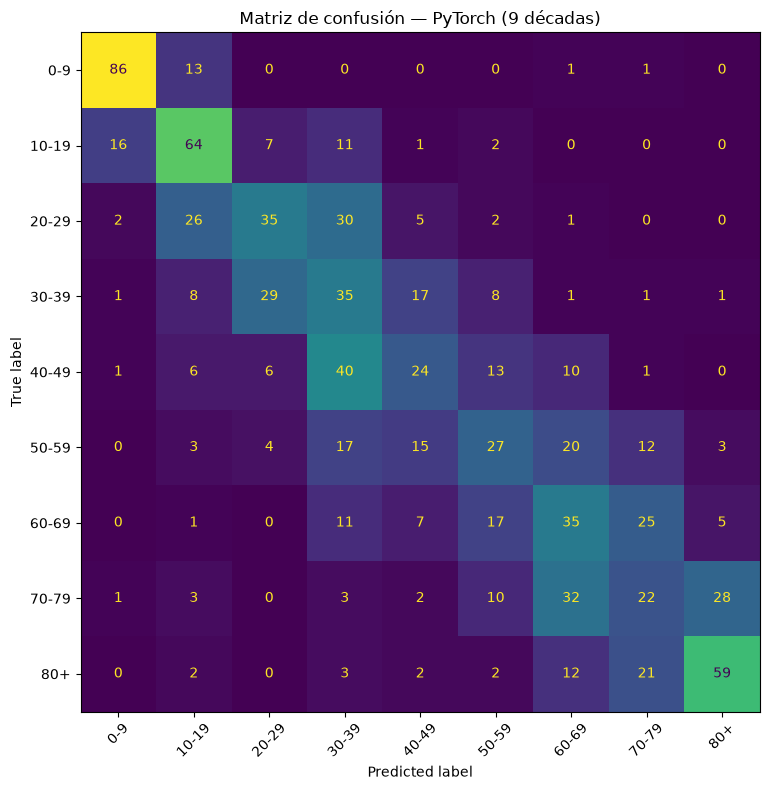

In [10]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — PyTorch (9 décadas)")
plt.tight_layout()
plt.show()

### Curva ROC — PyTorch

Curva ROC multiclase (One-vs-Rest): cada clase se compara contra el resto. El AUC resume la curva en un número: cercano a **1.0** = excelente separación, **0.5** = equivale al azar. La curva punteada negra es el **micro-promedio** (todas las clases juntas).

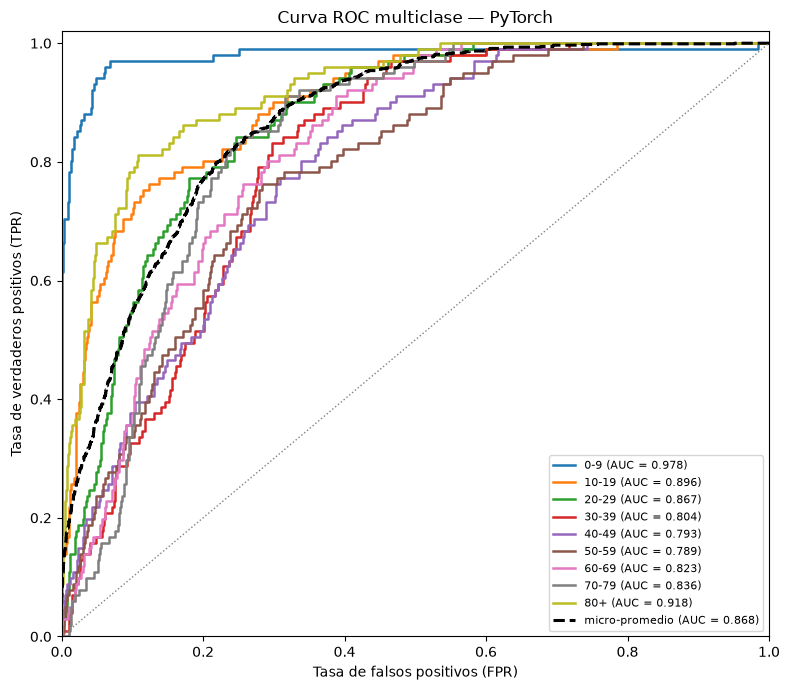

In [11]:
# --- Curva ROC (PyTorch) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Recolectamos las probabilidades (softmax) del modelo sobre el set de test.
model_pt.eval()
probs_pt, y_roc_pt = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        p = F.softmax(model_pt(imgs), dim=1)
        probs_pt.extend(p.cpu().numpy())
        y_roc_pt.extend(labels.numpy())
probs_pt = np.array(probs_pt)
y_roc_pt = np.array(y_roc_pt)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_pt, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_pt[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

# Micro-promedio: junta todas las clases en una sola curva global.
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_pt.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — PyTorch")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Parte B: TensorFlow / Keras


In [12]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [13]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,161 (2.09 MB)

 Trainable params: 549,161 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- Entrenamiento (Keras) ---
ti2=time.time()
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)
tf2=time.time()
t_total_tf = tf2 - ti2
print(f"\nTiempo total de entrenamiento (Keras): {t_total_tf:.2f} segundos")

Epoch 1/10


c:\Users\fsali\Documents\GitHub\frameworks-ia-2026_udd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.1467 - loss: 2.1725 - val_accuracy: 0.2310 - val_loss: 2.0159
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2729 - loss: 1.9035 - val_accuracy: 0.3355 - val_loss: 1.7432
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3307 - loss: 1.6966 - val_accuracy: 0.3564 - val_loss: 1.6041
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3744 - loss: 1.5950 - val_accuracy: 0.3707 - val_loss: 1.5373
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4025 - loss: 1.5046 - val_accuracy: 0.3608 - val_loss: 1.5685
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4201 - loss: 1.4260 - val_accuracy: 0.3784 - val_loss: 1.4723
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4482 - loss: 1.3726 - val_accuracy: 0.3960 - val_loss: 1.4425
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4728 - loss: 1.3076 - val_accuracy: 0.394

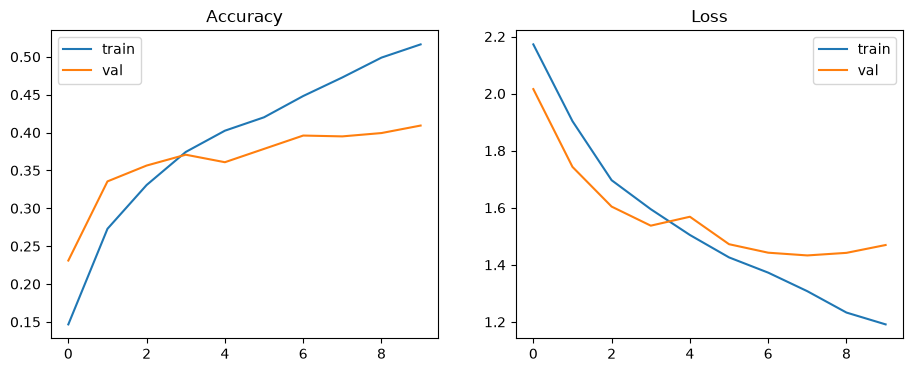

In [15]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

         0-9       0.75      0.88      0.81       101
       10-19       0.52      0.49      0.50       101
       20-29       0.39      0.41      0.40       101
       30-39       0.30      0.17      0.22       101
       40-49       0.34      0.40      0.37       101
       50-59       0.26      0.26      0.26       101
       60-69       0.41      0.29      0.34       101
       70-79       0.23      0.27      0.25       101
         80+       0.53      0.68      0.60       101

    accuracy                           0.43       909
   macro avg       0.42      0.43      0.42       909
weighted avg       0.42      0.43      0.42       909



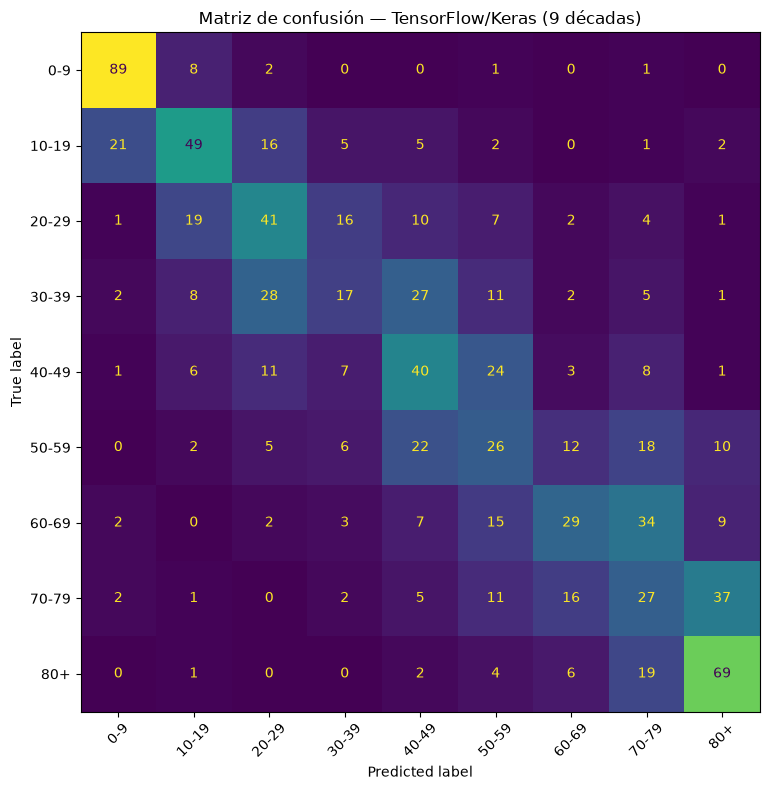

In [16]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — TensorFlow/Keras (9 décadas)")
plt.tight_layout()
plt.show()

### Curva ROC — TensorFlow/Keras

Misma lectura que la ROC de PyTorch, ahora para el modelo de Keras. Sirve para comparar la capacidad de separación de ambos frameworks clase por clase.

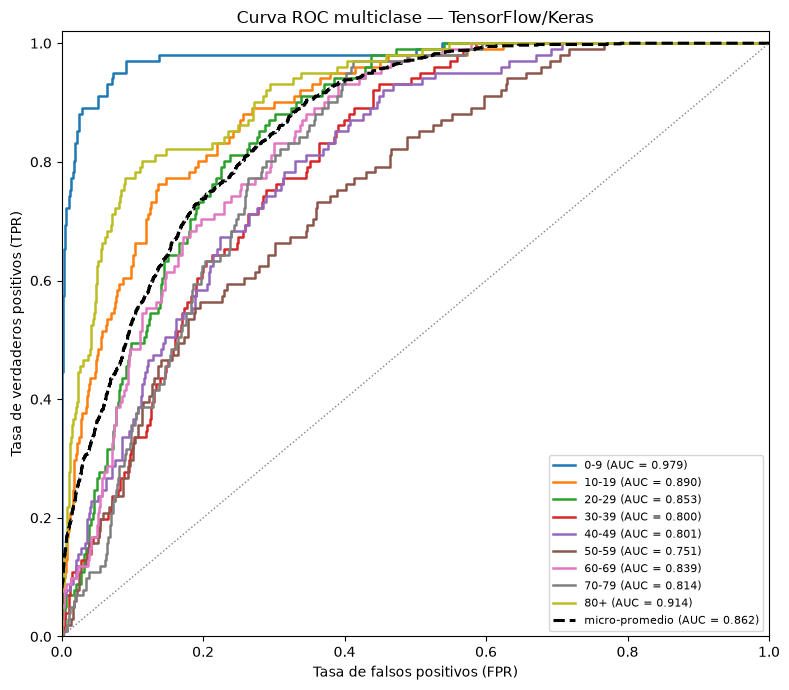

In [17]:
# --- Curva ROC (Keras) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# El modelo de Keras ya entrega softmax en su capa final.
probs_tf, y_roc_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    probs_tf.extend(preds)
    y_roc_tf.extend(labels.numpy())
probs_tf = np.array(probs_tf)
y_roc_tf = np.array(y_roc_tf)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_tf, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_tf[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_tf.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — TensorFlow/Keras")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Comparación final

Los dos frameworks llegaron prácticamente al mismo resultado: una accuracy cercana a 0.43 y un F1 macro cercano a 0.42 en test (PyTorch quedó en accuracy 0.43 y F1 0.42, y Keras en accuracy 0.43 y F1 0.42). Es decir, el framework no es el factor que limita el desempeño acá, porque ambos convergen al mismo techo.

El problema real son las 9 categorías, no el modelo. Si miramos el F1 por clase, el patrón se repite en ambos frameworks: los extremos se salvan, con la clase 0-9 en torno a 0.83 y la clase 80+ cerca de 0.60, pero todas las décadas intermedias, desde 30-39 hasta 70-79, caen a un F1 de entre 0.25 y 0.35 aproximadamente, donde el modelo apenas supera el azar. Al partir la edad en 9 tramos de 10 años, las fronteras entre décadas vecinas quedan tan finas que una persona de 39 y una de 41 se ven casi iguales, y el modelo no tiene cómo separarlas.  

### **La conclusión es clara: subir a tantas categorías no fue una buena idea, porque el F1 se desploma.**  

Por eso, en el siguiente notebook (4to_analisis) volvemos a rangos más anchos, con solo 5 segmentos, y además estudiamos cómo se comporta el modelo si eliminamos el sesgo generado por la etnia. Para ello balanceamos el dataset no solo por edad sino también por etnia, de modo que el modelo no aprenda a adivinar la edad apoyándose en rasgos étnicos en vez de en rasgos propios del envejecimiento.



## Prueba 

Test hecho con fotos propias y algunas fotos sacadas del dataset. Estas están en la carpeta fotos_prueba.


Fotos encontradas: 16


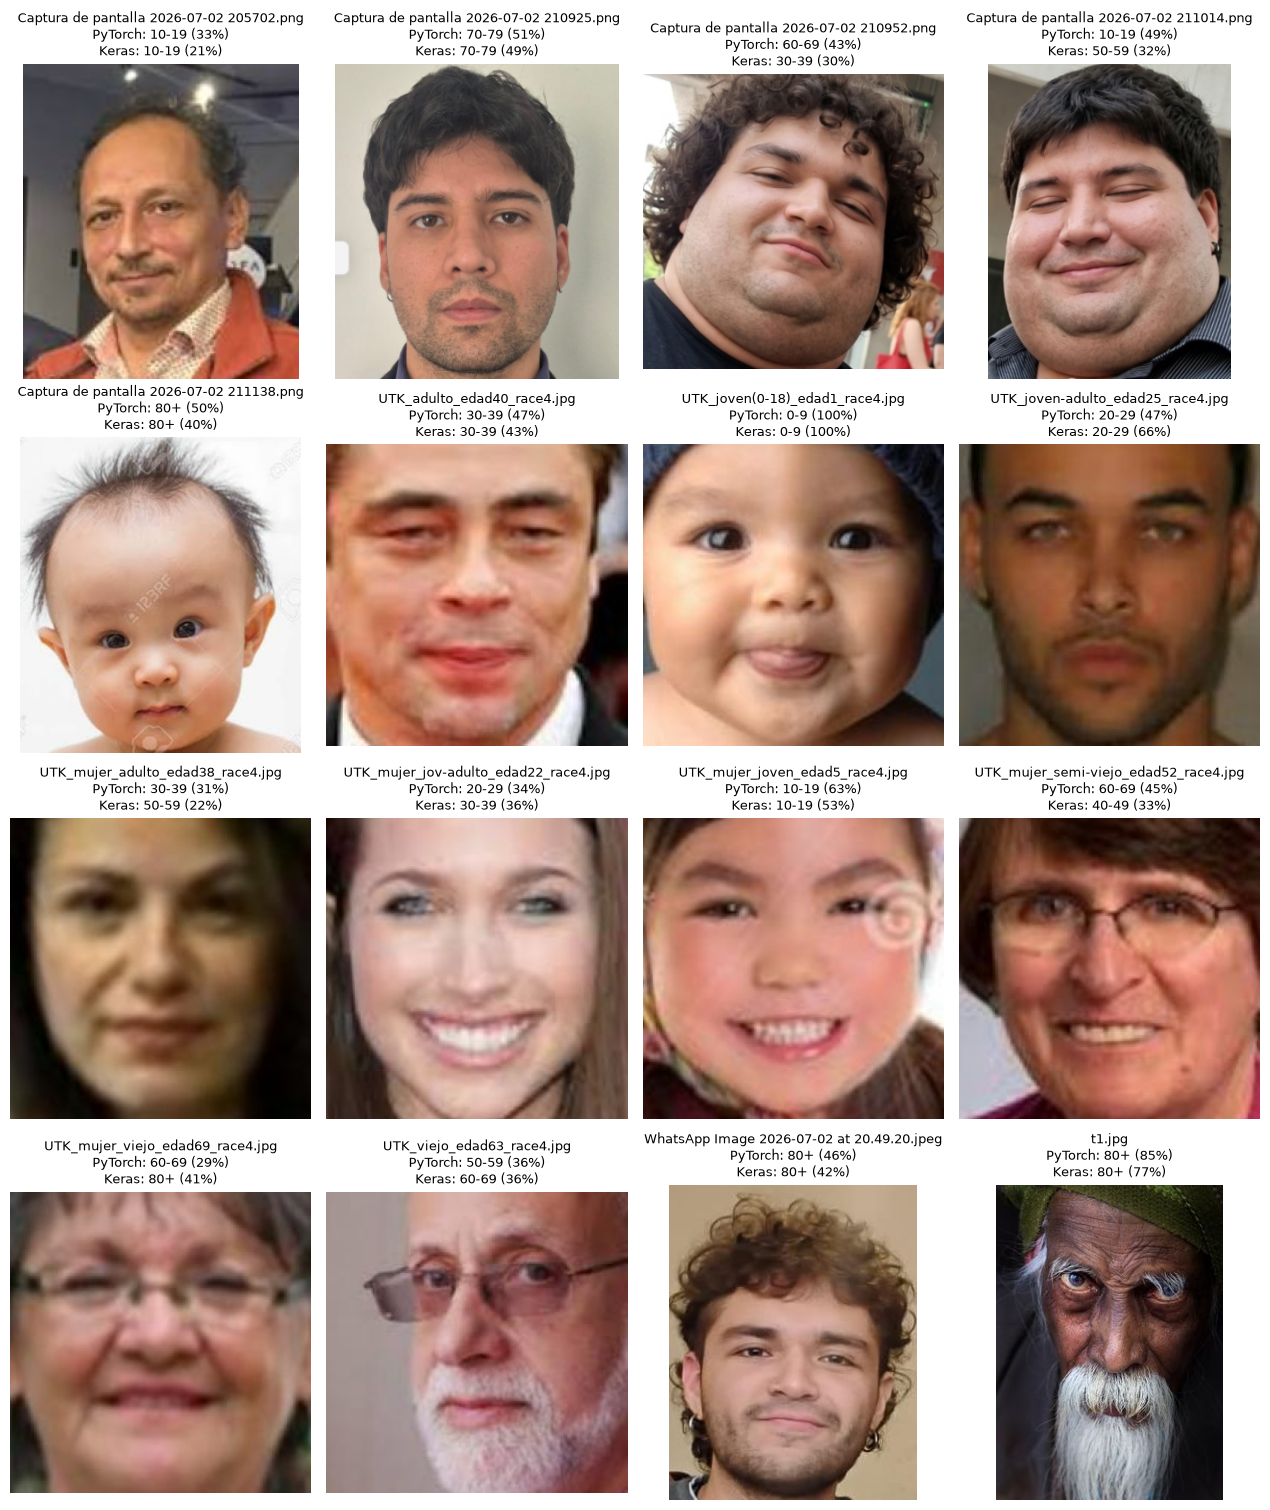

In [18]:
# --- Prueba con imágenes propias ---
# 1) Deja tus fotos (una cara por imagen) en la carpeta FOTOS_PRUEBA.
# 2) Ejecuta esta celda DESPUÉS de haber entrenado los modelos más arriba.
import glob
from PIL import Image

FOTOS_PRUEBA = "./fotos_prueba"   # <-- carpeta con tus imágenes de prueba

exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
rutas = []
for e in exts:
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e))
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e.upper()))
rutas = sorted(set(rutas))

if len(rutas) == 0:
    raise FileNotFoundError(
        f"No encontré imágenes en '{FOTOS_PRUEBA}'. Crea la carpeta y deja adentro "
        "algunas fotos (jpg o png), con una cara por imagen."
    )
print(f"Fotos encontradas: {len(rutas)}")

tiene_pt = "model_pt" in globals()   # modelo PyTorch entrenado
tiene_tf = "model_tf" in globals()   # modelo Keras entrenado

def predecir_pytorch(img_pil):
    model_pt.eval()
    x = transform(img_pil).unsqueeze(0).to(device)   # mismo preprocesamiento del entrenamiento
    with torch.no_grad():
        probs = torch.softmax(model_pt(x), dim=1)[0].cpu().numpy()
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx])

def predecir_keras(img_pil):
    arr = np.asarray(img_pil.resize((IMG_SIZE, IMG_SIZE)), dtype="float32") / 255.0
    probs = model_tf.predict(arr[None, ...], verbose=0)[0]
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx])

# Muestra las fotos en una grilla con la predicción de cada modelo
n = len(rutas)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.8))
axes = np.array(axes).reshape(-1)

for ax, ruta in zip(axes, rutas):
    img = Image.open(ruta).convert("RGB")
    lineas = [os.path.basename(ruta)]
    if tiene_pt:
        lab, p = predecir_pytorch(img)
        lineas.append(f"PyTorch: {lab} ({p*100:.0f}%)")
    if tiene_tf:
        lab, p = predecir_keras(img)
        lineas.append(f"Keras: {lab} ({p*100:.0f}%)")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("\n".join(lineas), fontsize=9)

for ax in axes[n:]:   # apaga los recuadros que sobran en la grilla
    ax.axis("off")

plt.tight_layout()
plt.show()
